# Week 3 Internship Task: Dimensionality Reduction with PCA
**Student Name:** Amin Khan  
**Registration No:** AIMLB01-8657  
**Course:** Machine Learning  

### Objective:
1. Load the preprocessed dataset from Week 2.
2. Fit StandardScaler and PCA on the training set only (preventing data leakage) and transform both train and test sets.
3. Apply PCA with n components equal to the total number of features (20) to analyze explained variance.
4. Plot a Scree Plot (bar chart of explained variance ratios).
5. Plot a Cumulative Explained Variance Curve and identify the number of components required to capture at least 95% of the variance.
6. Retrain the best model from Week 2 (Random Forest: `n_estimators=50`, `max_depth=15`, `random_state=42`) using:
   - Only 3 PCA components.
   - The number of components that capture 95% of variance.
7. Compare RMSE and R-squared across the original model, 3-component PCA, and 95% variance PCA models.
8. Create a loading heatmap mapping original features to the first 3 principal components.
9. Serialize the final pipeline (Scaler + PCA + Random Forest) using `joblib` for local FastAPI dashboard deployment.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Configure matplotlib formatting for high-quality figures
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True


In [2]:
# Locate and load the preprocessed steel industry energy consumption dataset from Week 2
data_path = '../../Week_2/Steel_industry_data/Steel_industry_data.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {os.path.abspath(data_path)}")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()


Dataset successfully loaded. Shape: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
# 1. Parse date and extract temporal features
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M', errors='coerce')
df['Hour'] = df['date'].dt.hour
df['DayOfWeek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['Month'] = df['date'].dt.month
df['IsWeekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# 2. Power Factor Ratio
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Define X and y (drop non-interpretable 'date', target 'Usage_kWh', and target-leaking 'High_Load')
X = df.drop(columns=['date', 'Usage_kWh', 'High_Load'], errors='ignore')
y = df['Usage_kWh']

# One-hot encode categorical features (Load_Type, Day_of_week, WeekStatus)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert booleans to 1/0 integers to prevent model warnings
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(int)

print(f"Dimensions after feature extraction and One-Hot Encoding: {X_encoded.shape}")
print("Final encoded feature names:")
for idx, col in enumerate(X_encoded.columns, 1):
    print(f"{idx:2d}: {col}")


Dimensions after feature extraction and One-Hot Encoding: (35040, 20)
Final encoded feature names:
 1: Lagging_Current_Reactive.Power_kVarh
 2: Leading_Current_Reactive_Power_kVarh
 3: CO2(tCO2)
 4: Lagging_Current_Power_Factor
 5: Leading_Current_Power_Factor
 6: NSM
 7: Hour
 8: DayOfWeek
 9: Month
10: IsWeekend
11: Power_Factor_Ratio
12: WeekStatus_Weekend
13: Day_of_week_Monday
14: Day_of_week_Saturday
15: Day_of_week_Sunday
16: Day_of_week_Thursday
17: Day_of_week_Tuesday
18: Day_of_week_Wednesday
19: Load_Type_Maximum_Load
20: Load_Type_Medium_Load


In [4]:
# Perform 80% train / 20% test split using the exact same random state as Week 2
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print("--- Train/Test Data Split ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")


--- Train/Test Data Split ---
X_train shape: (28032, 20) | y_train shape: (28032,)
X_test shape:  (7008, 20)  | y_test shape:  (7008,)


In [5]:
# Fit StandardScaler on the training set only and transform both to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")


Features scaled successfully.


In [6]:
# Fit PCA with n_components equal to the total number of features (20)
pca = PCA(n_components=X_train.shape[1])
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio per component:")
for idx, val in enumerate(explained_variance_ratio, 1):
    print(f"PC{idx:02d}: {val*100:6.2f}% (Cumulative: {cumulative_variance[idx-1]*100:6.2f}%)")


Explained variance ratio per component:
PC01:  24.73% (Cumulative:  24.73%)
PC02:  19.95% (Cumulative:  44.68%)
PC03:  11.02% (Cumulative:  55.70%)
PC04:   6.61% (Cumulative:  62.32%)
PC05:   6.17% (Cumulative:  68.48%)
PC06:   5.84% (Cumulative:  74.32%)
PC07:   5.83% (Cumulative:  80.16%)
PC08:   5.42% (Cumulative:  85.58%)
PC09:   5.15% (Cumulative:  90.74%)
PC10:   4.28% (Cumulative:  95.02%)
PC11:   1.79% (Cumulative:  96.80%)
PC12:   1.48% (Cumulative:  98.28%)
PC13:   1.14% (Cumulative:  99.43%)
PC14:   0.34% (Cumulative:  99.76%)
PC15:   0.21% (Cumulative:  99.97%)
PC16:   0.03% (Cumulative: 100.00%)
PC17:   0.00% (Cumulative: 100.00%)
PC18:   0.00% (Cumulative: 100.00%)
PC19:   0.00% (Cumulative: 100.00%)
PC20:   0.00% (Cumulative: 100.00%)


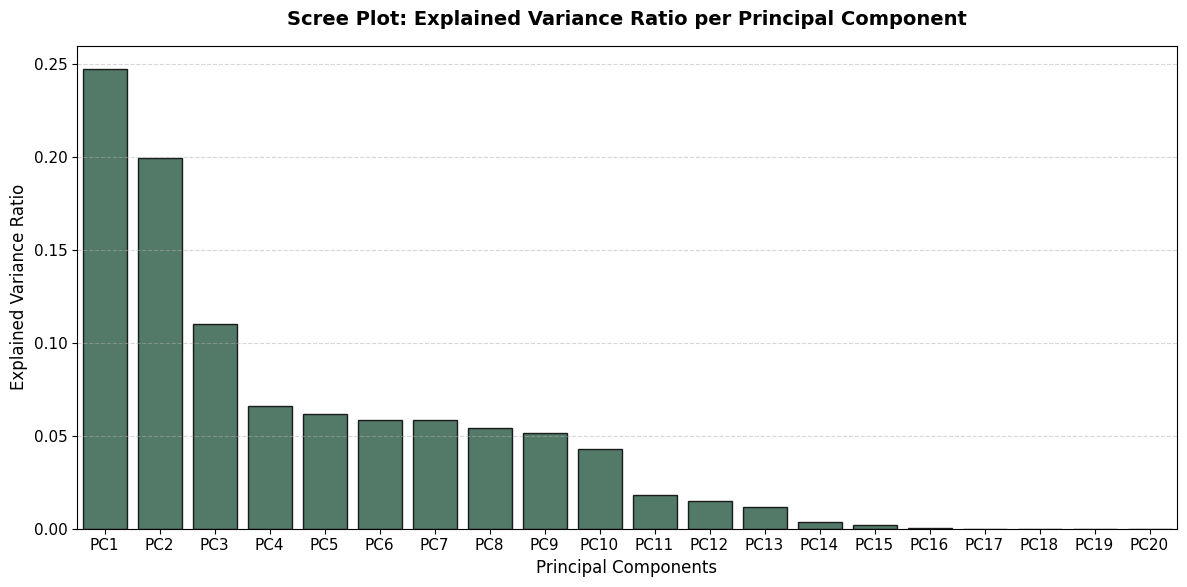

In [7]:
# 4. Plot Scree Plot (explained variance ratio of each principal component)
plt.figure(figsize=(12, 6))
sns.barplot(x=[f"PC{i}" for i in range(1, len(explained_variance_ratio)+1)], 
            y=explained_variance_ratio, 
            color='#2d6a4f', 
            edgecolor='black', 
            alpha=0.85)

plt.title('Scree Plot: Explained Variance Ratio per Principal Component', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150)
plt.show()


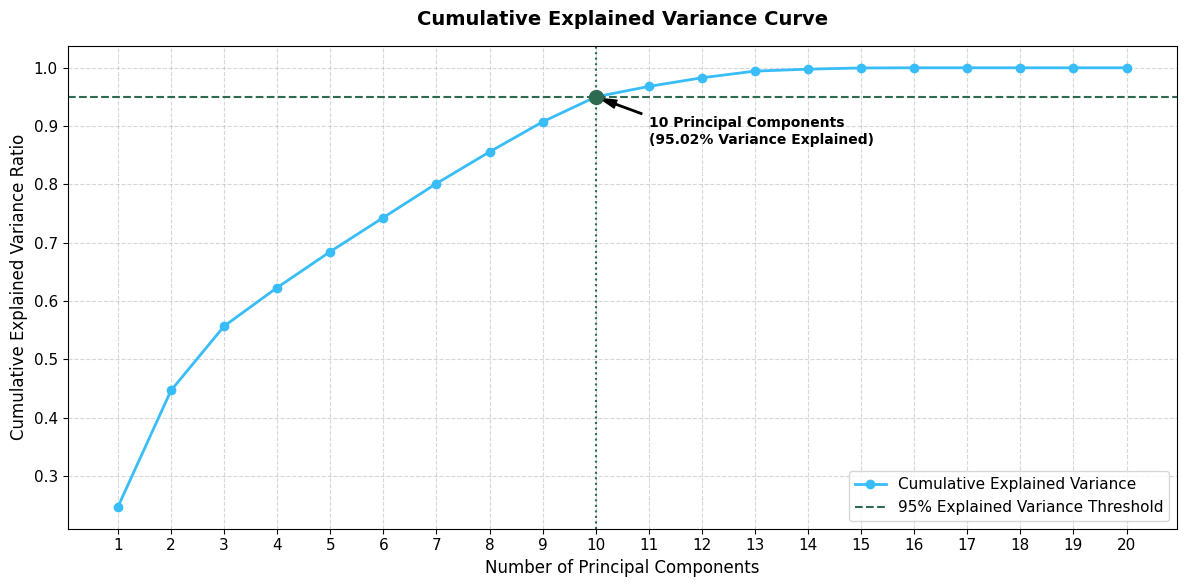

We need 10 principal components to capture at least 95% of the variance.


In [8]:
# 5. Plot Cumulative Explained Variance Curve and find the 95% threshold
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='#38bdf8', linewidth=2, label='Cumulative Explained Variance')
plt.axhline(y=0.95, color='#2d6a4f', linestyle='--', linewidth=1.5, label='95% Explained Variance Threshold')

# Find the exact component number that reaches or exceeds 95% cumulative variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(x=n_components_95, color='#2d6a4f', linestyle=':', linewidth=1.5)

plt.title('Cumulative Explained Variance Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight and annotate the threshold point
plt.scatter(n_components_95, cumulative_variance[n_components_95-1], color='#2d6a4f', s=100, zorder=5)
plt.annotate(f'{n_components_95} Principal Components\n({cumulative_variance[n_components_95-1]*100:.2f}% Variance Explained)', 
             xy=(n_components_95, cumulative_variance[n_components_95-1]), 
             xytext=(n_components_95 + 1, cumulative_variance[n_components_95-1] - 0.08),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cumulative_variance_plot.png', dpi=150)
plt.show()

print(f"We need {n_components_95} principal components to capture at least 95% of the variance.")


In [9]:
# Evaluation helper function to fit the Random Forest model and compute test metrics
def evaluate_rf(X_tr, X_te, y_tr, y_te, title):
    rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    
    print(f"=== {title} Performance ===")
    print(f"Test MAE:  {mae:.4f} kWh")
    print(f"Test RMSE: {rmse:.4f} kWh")
    print(f"Test R^2:  {r2:.4f}\n")
    
    return rmse, r2, rf


In [10]:
# 6. Fit the model using all original features (20 inputs)
rmse_orig, r2_orig, model_orig = evaluate_rf(X_train_scaled, X_test_scaled, y_train, y_test, "Original Scaled Model")


=== Original Scaled Model Performance ===
Test MAE:  0.4344 kWh
Test RMSE: 1.1470 kWh
Test R^2:  0.9988



In [11]:
# 7. Fit the model using exactly 3 PCA components
X_train_pca_3 = X_train_pca[:, :3]
X_test_pca_3 = X_test_pca[:, :3]
rmse_pca_3, r2_pca_3, model_pca_3 = evaluate_rf(X_train_pca_3, X_test_pca_3, y_train, y_test, "3-Component PCA Model")


=== 3-Component PCA Model Performance ===
Test MAE:  3.5846 kWh
Test RMSE: 7.3615 kWh
Test R^2:  0.9523



In [12]:
# 8. Fit the model using the number of components representing 95% variance
X_train_pca_95 = X_train_pca[:, :n_components_95]
X_test_pca_95 = X_test_pca[:, :n_components_95]
rmse_pca_95, r2_pca_95, model_pca_95 = evaluate_rf(X_train_pca_95, X_test_pca_95, y_train, y_test, f"{n_components_95}-Component PCA Model (95% Var)")


=== 10-Component PCA Model (95% Var) Performance ===
Test MAE:  1.7685 kWh
Test RMSE: 3.3800 kWh
Test R^2:  0.9899



In [13]:
# Combine metrics into a single comparison DataFrame
comparison_df = pd.DataFrame({
    'Model Configuration': [
        'Original Model (Week 2)', 
        '3-Component PCA Model', 
        f'95% Variance PCA Model ({n_components_95} PCs)'
    ],
    'Number of Input Features': [X_train.shape[1], 3, n_components_95],
    'Test RMSE (kWh)': [rmse_orig, rmse_pca_3, rmse_pca_95],
    'Test R-squared (R^2)': [r2_orig, r2_pca_3, r2_pca_95]
})

print("--- PCA Dimensionality Reduction Comparison Table ---")
display(comparison_df)


--- PCA Dimensionality Reduction Comparison Table ---


,Model Configuration,Number of Input Features,Test RMSE (kWh),Test R-squared (R^2)
0,Original Model (Week 2),20,1.147019,0.998843
1,3-Component PCA Model,3,7.361489,0.952327
2,95% Variance PCA Model (10 PCs),10,3.379990,0.989950


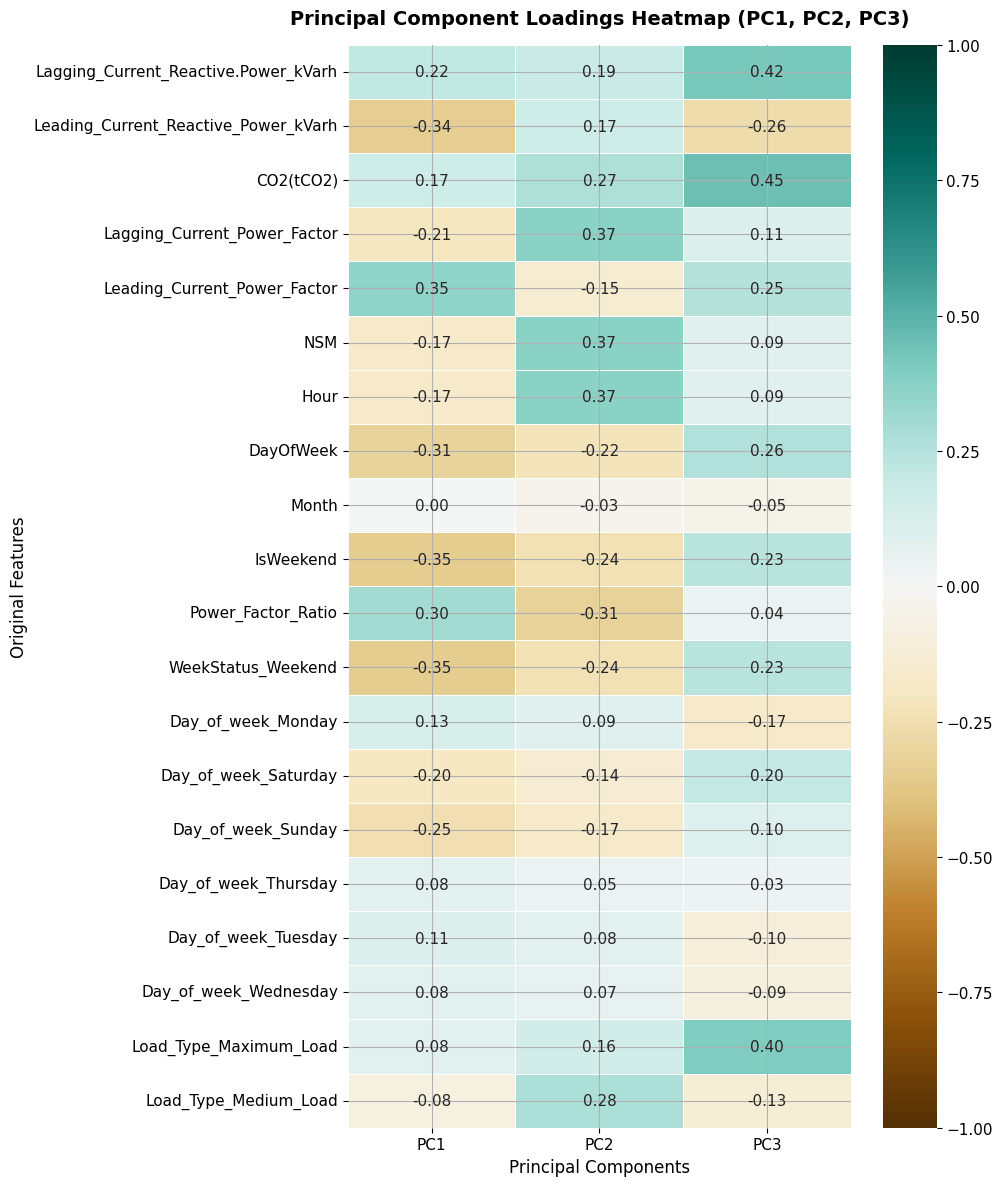

In [14]:
# 9. Create a loading heatmap of original features against the first 3 components
loadings = pca.components_[:3].T # components_ shape is (n_components, n_features)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'], index=X_train.columns)

# Render heatmap using seaborn
plt.figure(figsize=(10, 12))
sns.heatmap(loadings_df, annot=True, cmap='BrBG', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, square=False)
plt.title('Principal Component Loadings Heatmap (PC1, PC2, PC3)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Original Features', fontsize=12)
plt.xlabel('Principal Components', fontsize=12)
plt.tight_layout()
plt.savefig('pca_loadings_heatmap.png', dpi=150)
plt.show()


In [15]:
# 10. Build and save the full pipeline (StandardScaler + PCA (95% var) + Random Forest Regressor)
# Note: The scaler and PCA will be fit on X_train inside the pipeline.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_95)),
    ('model', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42))
])

# Fit on unscaled encoded features X_train and targets y_train
pipeline.fit(X_train, y_train)

# Double check that pipeline predictions match manual steps
pipeline_preds = pipeline.predict(X_test)
pipe_rmse = np.sqrt(mean_squared_error(y_test, pipeline_preds))
pipe_r2 = r2_score(y_test, pipeline_preds)

print("--- Pipeline Verification ---")
print(f"Pipeline Test RMSE: {pipe_rmse:.4f} (Manual was {rmse_pca_95:.4f})")
print(f"Pipeline Test R^2:  {pipe_r2:.4f} (Manual was {r2_pca_95:.4f})")

# Save model pipeline using joblib
model_save_path = '../model.joblib'
joblib.dump(pipeline, model_save_path)
print(f"Successfully saved pipeline to {os.path.abspath(model_save_path)}")


--- Pipeline Verification ---
Pipeline Test RMSE: 3.3800 (Manual was 3.3800)
Pipeline Test R^2:  0.9899 (Manual was 0.9899)
Successfully saved pipeline to D:\ITSimplera\Week_3\model.joblib
